# GETTING STARTED

In [1]:
import juliet
import numpy as np
import matplotlib.pyplot as plt


ERROR:   Could not load MultiNest library "libmultinest.so"
ERROR:   You have to build it first,
ERROR:   and point the LD_LIBRARY_PATH environment variable to it!
ERROR:   manual: https://johannesbuchner.github.io/PyMultiNest/install.html


ERROR:   Could not load MultiNest library: libmultinest.so
ERROR:   You have to build MultiNest,
ERROR:   and point the LD_LIBRARY_PATH environment variable to it!
ERROR:   manual: https://johannesbuchner.github.io/PyMultiNest/install.html

problem: libmultinest.so: cannot open shared object file: No such file or directory


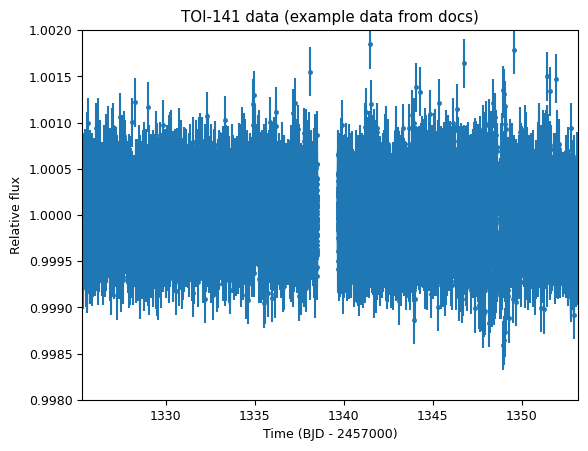

In [2]:
t,f,ferr  = juliet.get_TESS_data('https://archive.stsci.edu/hlsps/tess-data-alerts/'+\
                                 'hlsp_tess-data-alerts_tess_phot_00403224672-'+\
                                 's01_tess_v1_lc.fits')

plt.errorbar(t, f, ferr, fmt='.')
plt.xlim(np.min(t), np.max(t))
plt.ylim(0.998, 1.002)
plt.title('TOI-141 data (example data from docs)')
plt.xlabel('Time (BJD - 2457000)')
plt.ylabel('Relative flux')
plt.show()


In [3]:
# Create dictionaries - this is the format Juliet likes:
times, fluxes, fluxes_error = {}, {}, {}
# Save data into those dictionaries:
times['TESS'], fluxes['TESS'], fluxes_error['TESS'] = t, f, ferr
# If you had data from other instruments you would simply do, e.g.,
# times['K2'], fluxes['K2'], fluxes_error['K2'] = t_k2,f_k2,ferr_k2
print(times)

{'TESS': array([1325.29973468, 1325.30112358, 1325.30251248, ..., 1353.17598911,
       1353.17737797, 1353.17876683], dtype='>f8')}


In [4]:
# Define priors for each parameter and their distributions
priors = {}

params = ['P_p1', 't0_p1', 'r1_p1', 'r2_p1', 'q1_TESS', 'q2_TESS', 'ecc_p1', 'omega_p1', 'rho', 'mdilution_TESS', 'mflux_TESS','sigma_w_TESS']
dists = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'fixed', 'fixed', 'loguniform', 'fixed', 'normal', 'loguniform']
# P: orbital period, days
# t0: mid-transit time, days
# r1, r2: parametrization for impact parameter and planet-to-star radius ratio (b, p)
# q1, q2: limb-darkening parameters
# ecc: eccentricity of orbit
# omega: argument of periastron, degrees
# rho: stellar density, kg/m^3
# mdilution: dilution factor depending on instrument
# mflux: mean out-of-transit flux
# sigma_w: jitter, ppm


# Define hyperparameters, for each distribution they represent...
# Normal: [mean, stdev]
# Uniform and Loguniform: [lower limit, upper limit]
# Fixed: fixed values
hyperps = [[1.,0.1], [1325.55,0.1], [0.,1], [0.,1.], [0., 1.], [0., 1.], 0.0, 90.,
                   [100., 10000.], 1.0, [0.,0.1], [0.1, 1000.]]

for param, dist, hyperp in zip(params, dists, hyperps):
    priors[param] = {}
    priors[param]['distribution'], priors[param]['hyperparameters'] = dist, hyperp

# print(priors)

In [5]:
# Load dataset int juliet, save results to out_folder. dataset.fit will run a dynesty fit
# If this detects existing dynesty output sampler files it won't have to run again
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_error, out_folder = 'toi141_fit')
results = dataset.fit(n_live_points = 300)

PyMultinest installation not detected. Forcing dynesty as the sampler.
Detected dynesty sampler output files --- extracting from toi141_fit/_dynesty_NS_posteriors.pkl


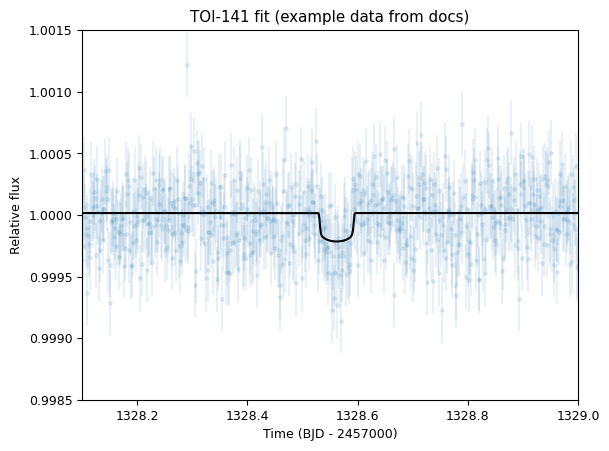

In [6]:
# Plot data and model
plt.errorbar(dataset.times_lc['TESS'], dataset.data_lc['TESS'], yerr = dataset.errors_lc['TESS'], fmt='.', alpha=0.1)
plt.plot(dataset.times_lc['TESS'], results.lc.evaluate('TESS'), color = 'k')

plt.xlim(1328.1, 1329)
plt.ylim(0.9985, 1.0015)
plt.title('TOI-141 fit (example data from docs)')
plt.xlabel('Time (BJD - 2457000)')
plt.ylabel('Relative flux')
plt.show()

# LIGHTCURVE FITTNG

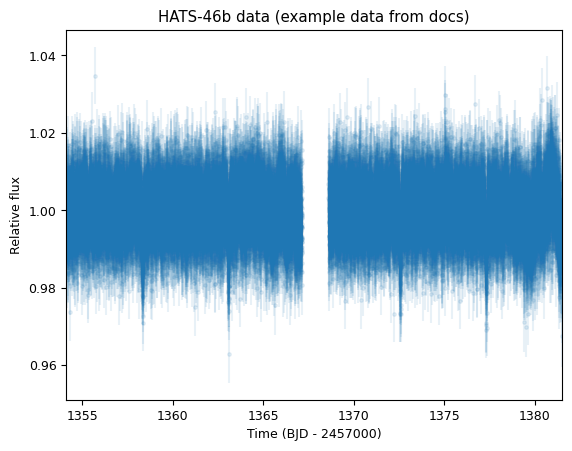

In [7]:
# Get another set of data
t2, f2, ferr2 = juliet.get_TESS_data('https://archive.stsci.edu/hlsps/tess-data-alerts/hlsp_tess-data-alerts_tess_phot_00281541555-s02_tess_v1_lc.fits')

plt.errorbar(t2, f2, yerr = ferr2, fmt = '.', alpha=0.1)
plt.xlim(np.min(t2), np.max(t2))
plt.title('HATS-46b data (example data from docs)')
plt.xlabel('Time (BJD - 2457000)')
plt.ylabel('Relative flux')
plt.show()

In [8]:
# Put data into dictionaries
times2, fluxes2, fluxes_error2 = {}, {}, {}
times2['TESS'], fluxes2['TESS'], fluxes_error2['TESS'] = t2, f2, ferr2

# Define priors, params, distributions
priors2 = {}
params2 = ['P_p1', 't0_p1', 'r1_p1', 'r2_p1', 'q1_TESS', 'q2_TESS', 'ecc_p1', 'omega_p1', 'rho', 'mdilution_TESS', 'mflux_TESS','sigma_w_TESS']
dists2 = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'fixed', 'fixed', 'loguniform', 'fixed', 'normal', 'loguniform']
hyperps2 = [[4.7,0.1], [1358.4,0.1], [0.,1], [0.,1.], [0., 1.], [0., 1.], 0.0, 90., [100., 10000.], 1.0, [0.,0.1], [0.1, 1000.]]

for param, dist, hyperp in zip(params2, dists2, hyperps2):
    priors2[param] = {}
    priors2[param]['distribution'], priors2[param]['hyperparameters'] = dist, hyperp

# Load and fit dataset
dataset2 = juliet.load(priors = priors2, t_lc = times2, y_lc = fluxes2, yerr_lc = fluxes_error2, out_folder = 'hats46')
results2 = dataset2.fit()

PyMultinest installation not detected. Forcing dynesty as the sampler.
Detected dynesty sampler output files --- extracting from hats46/_dynesty_NS_posteriors.pkl


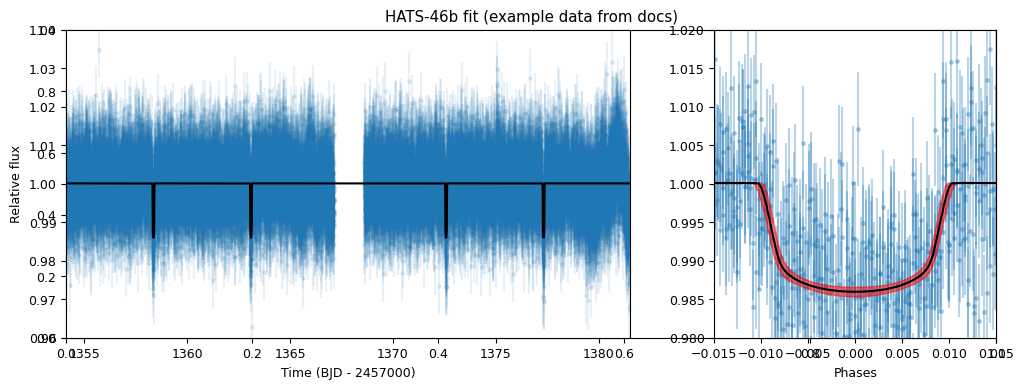

In [9]:
import matplotlib.gridspec as gridspec

# We can not only plot a best fit curve through our data points, but also +/- 1 r'$\sigma$' band around the median fit
transit_model, transit_up68, transit_low68 = results2.lc.evaluate('TESS', return_err=True)

# Get median period and mid-transit time - this will make a subplot showing an individual phase
P, t0 = np.median(results2.posteriors['posterior_samples']['P_p1']), np.median(results2.posteriors['posterior_samples']['t0_p1'])
phases = juliet.get_phases(dataset2.times_lc['TESS'], P, t0)


# Plot two figures, time vs flux on left and single phase on right
fig = plt.figure(figsize = (12, 4))
gs = gridspec.GridSpec(1, 2, width_ratios = [2, 1])
plt.title('HATS-46b fit (example data from docs)')
ax1 = plt.subplot(gs[0])        # Left plot
ax2 = plt.subplot(gs[1])        # Right plot

# Scatter data
ax1.errorbar(dataset2.times_lc['TESS'], dataset2.data_lc['TESS'], yerr = dataset2.errors_lc['TESS'], fmt='.', alpha = 0.1)
ax2.errorbar(phases, dataset2.data_lc['TESS'], yerr = dataset2.errors_lc['TESS'], fmt='.', alpha = 0.3)

# Left plot
ax1.plot(dataset2.times_lc['TESS'], transit_model, color = 'k', zorder = 10)        # Median model
ax1.set_xlim(1354.11, 1381.52)
ax1.set_ylim(0.96, 1.04)
ax1.set_xlabel('Time (BJD - 2457000)')
ax1.set_ylabel('Relative flux')

# Right plot
idx = np.argsort(phases)
ax2.plot(phases[idx], transit_model[idx], color = 'k', zorder = 10)
ax2.fill_between(phases[idx], transit_up68[idx], transit_low68[idx], color = 'r', alpha = 0.5, zorder = 5)
ax2.set_xlabel('Phases')
ax2.set_xlim(-0.015,0.015)
ax2.set_ylim(0.98,1.02)

plt.show()

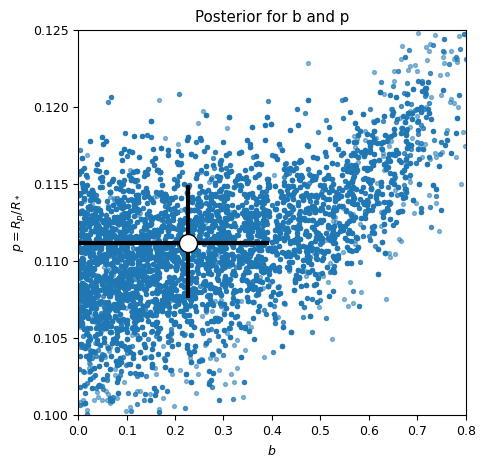

In [35]:
# Nowe we should look into transforming r1 + r2 and q1 + q2 into physical values
# --> p = Rp/Rs and b = (a/Rs)*cos(i) for r1 and r2; u1 and u2 for q1 and q2

# r1 + r2 --> b, p
fig = plt.figure(figsize = (5, 5))

# Fetch r1 and r2 posterior from results, convert to b and p and scatter data
r1, r2 = results2.posteriors['posterior_samples']['r1_p1'], results2.posteriors['posterior_samples']['r2_p1']
b, p = juliet.utils.reverse_bp(r1, r2, 0., 1.)      # Default upper/lower bounds are 0 and 1, can modify in dataset.fit(..., pl = 0.0, pu = 0.2)
plt.scatter(b, p, alpha = 0.5, s = 8)

# Get median, +1 sigma, -1 sigma errors and plot
bm, bu, bl = juliet.utils.get_quantiles(b)
pm, pu, pl = juliet.utils.get_quantiles(p)

plt.errorbar(np.array([bm]), np.array([pm]), xerr = np.array([[bu-bm], [bm-bl]]), yerr = np.array([[pu-pm], [pm-pl]]),
             fmt = 'o', mfc = 'w', mec = 'k', ecolor = 'k', ms = 13, elinewidth = 3, zorder = 5)

plt.xlim(0., 0.8)
plt.ylim(0.1, 0.125)
plt.title('Posterior for b and p')
plt.xlabel('$b$')
plt.ylabel('$p = R_p/R_*$')
plt.show()
# For some reason the median value and the errorbars are off from what they have on the docs

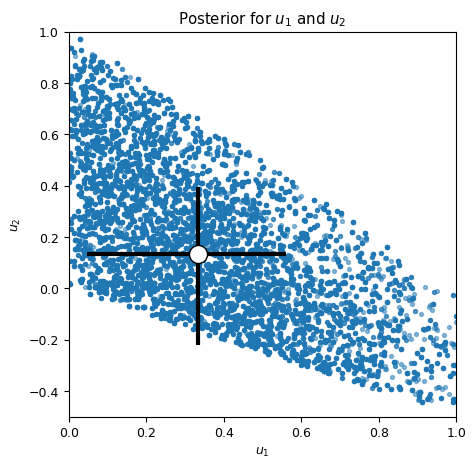

In [36]:
# q1 + q2 --> u1 + u2, similar process to r1 + r2 --> b + p
fig2 = plt.figure(figsize = (5, 5))

# Fetch q1 and q2 posterior from results, convert to u1 and u2 and scatter data
q1, q2 = results2.posteriors['posterior_samples']['q1_TESS'], results2.posteriors['posterior_samples']['q2_TESS']
u1, u2 = juliet.utils.reverse_ld_coeffs('quadratic', q1, q2)
plt.scatter(u1, u2, alpha = 0.5, s = 8)

# Get median, +1 sigma, -1 sigma errors and plot
u1m, u1u, u1l = juliet.utils.get_quantiles(u1)
u2m, u2u, u2l = juliet.utils.get_quantiles(u2)

plt.errorbar(np.array([u1m]), np.array([u2m]), xerr = np.array([[u1u-u1m], [u1m-u1l]]), yerr = np.array([[u2u-u2m], [u2m-u2l]]),
             fmt = 'o', mfc = 'w', mec = 'k', ecolor = 'k', ms = 13, elinewidth = 3, zorder = 5)

plt.title('Posterior for $u_1$ and $u_2$')
plt.xlabel('$u_1$')
plt.ylabel('$u_2$')
plt.xlim(0., 1.)
plt.ylim(-0.5, 1.)
plt.show()